<h2>Лабораторна робота №4</h2>
<h3>Моделювання функції двох змінних з двома входами і одним виходом на основі нейронних мереж</h3>


--- Training Model: Feedforward (1 layer, 10 neurons) ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


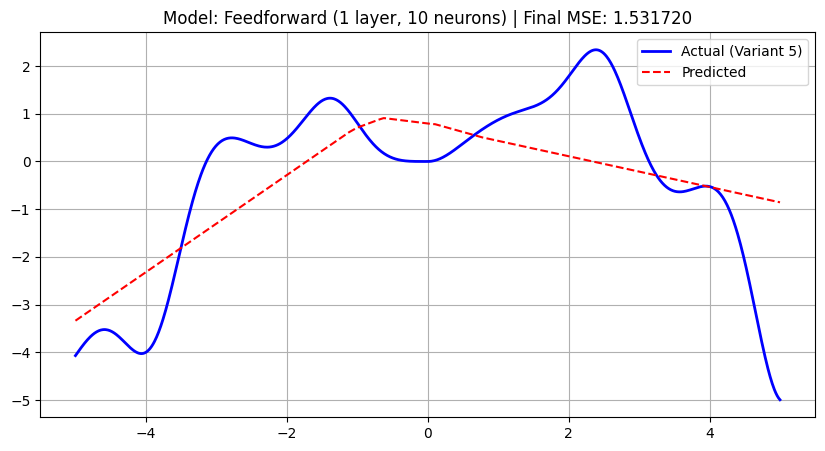


--- Training Model: Feedforward (1 layer, 20 neurons) ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


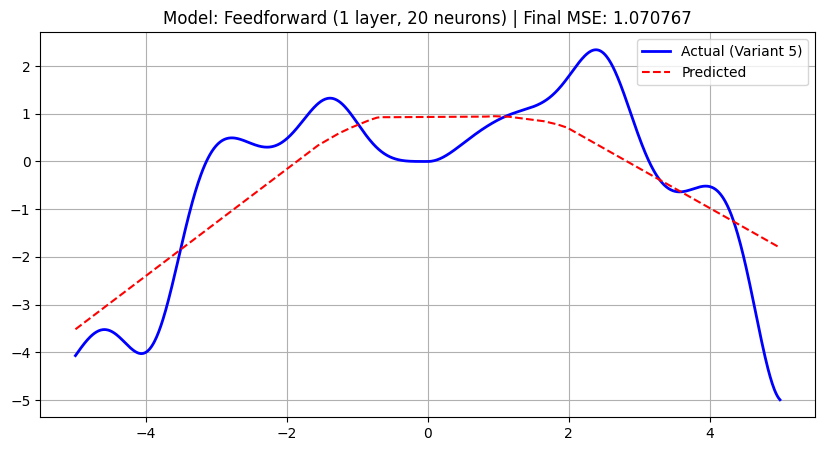


--- Training Model: Cascade (1 layer, 20 neurons) ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


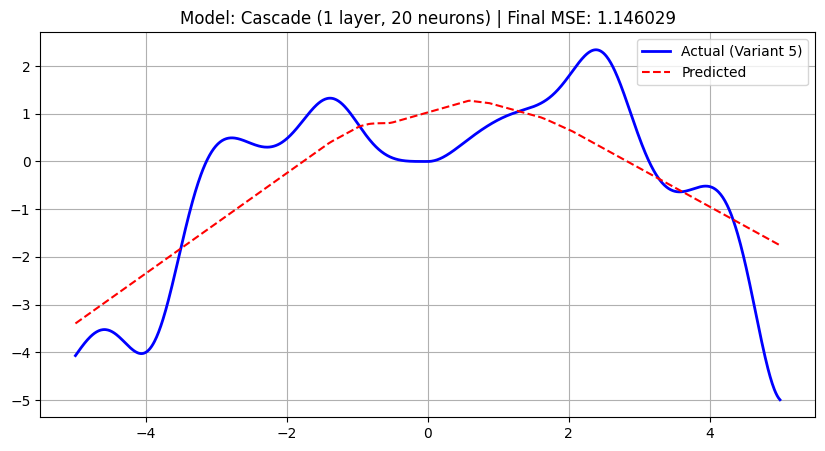


--- Training Model: Cascade (2 layers, 10 neurons) ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


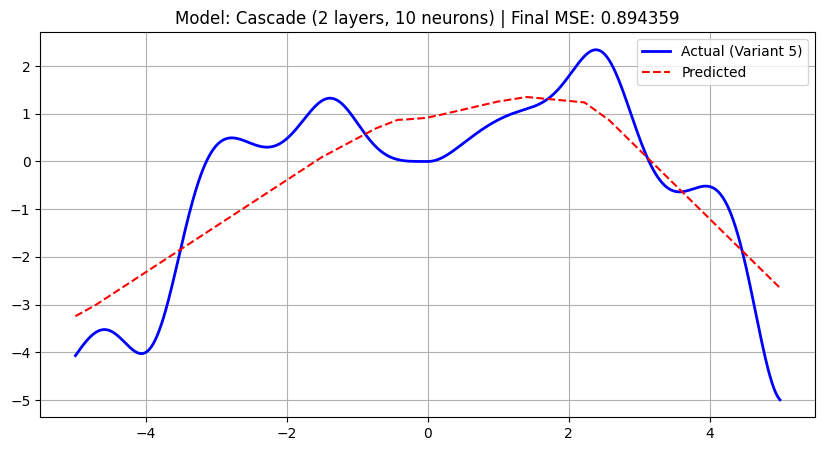


--- Training Model: Elman (1 layer, 15 neurons) ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


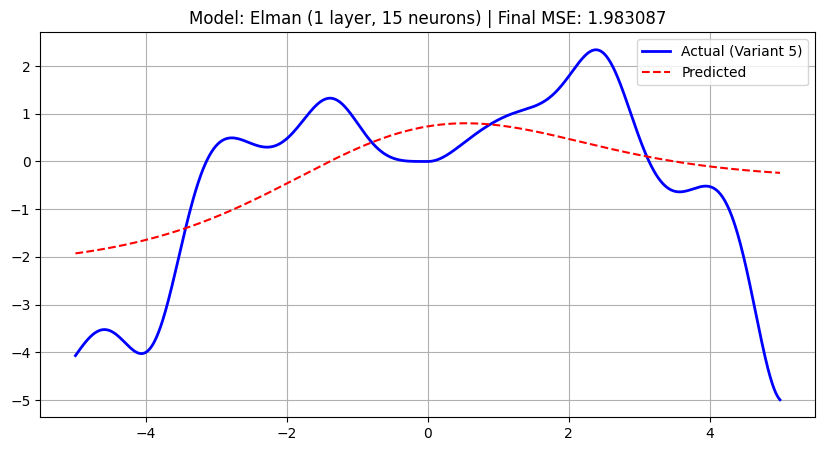


--- Training Model: Elman (3 layers, 5 neurons) ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


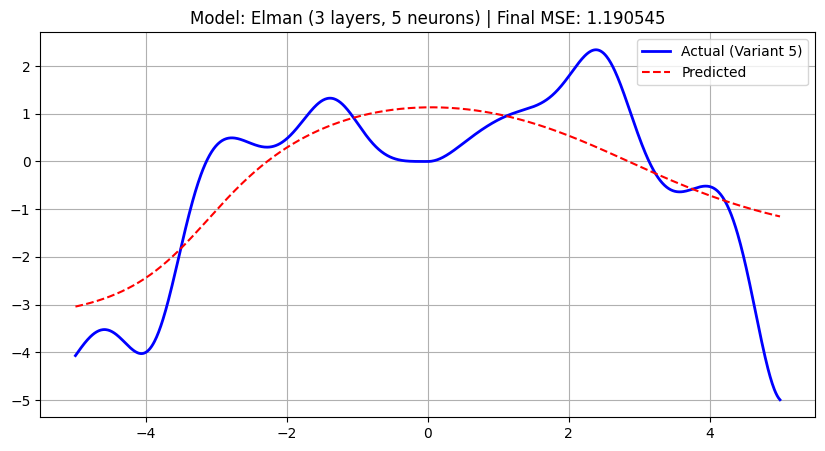

In [2]:
# !!! Немає діскретної відеокарти на моєму ноутбуці

import numpy as np # Імпортується бібліотеку NumPy для роботи з масивами та математичними операціями
import warnings # Імпортується модуль для керування попередженнями Python.

# Вимикаються всі попередження, щоб вони не відображались у консолі
warnings.filterwarnings("ignore")

# Імпортується модуль для роботи з операційною системою
import os
# Приховуються інформаційні та попереджувальні повідомлення TensorFlow (показуються лише критичні помилки)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
# Дозволяється запуск TensorFlow навіть при дублюванні бібліотек OpenMP (часта проблема на Linux)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# Імпортується система логування Python
import logging 
# Встановлюється рівень логування TensorFlow на FATAL (тільки критичні помилки)
logging.getLogger("tensorflow").setLevel(logging.FATAL)
# Повністю вимикається логування TensorFlow
logging.getLogger('tensorflow').disabled = True

# Імпортується спеціальну функцію для придушення повідомлень TensorFlow.
from silence_tensorflow import silence_tensorflow
silence_tensorflow("NONE") # Додатково вимикаються всі повідомлення TensorFlow

# Імпортується бібліотека TensorFlow для створення нейронних мереж
import tensorflow as tf
# Встановлюється мінімальний рівень логування TensorFlow
tf.get_logger().setLevel('FATAL') 
os.system('clear') # Очищається консоль (у Linux)

# Імпортує модуль логування Abseil (використовується TensorFlow)
import absl.logging

# Всі повідомлення Abseil ігноруються системою
absl.logging.get_absl_handler().python_handler.stream = open(os.devnull, 'w')
# Встановлюється найвищий рівень фільтрації повідомлень
absl.logging.set_verbosity(absl.logging.FATAL)
# Забороняється вивід повідомлень нижче рівня FATAL
absl.logging.set_stderrthreshold(absl.logging.FATAL)


# Імпортується бібліотека Matplotlib для побудови графіків
import matplotlib.pyplot as plt
# Імпортуються два типи моделей: Sequential — послідовна модель, Model — функціональна модель
from tensorflow.keras.models import Sequential, Model
# Імпортує шари нейронних мереж: Dense — повнозв’язний шар, SimpleRNN — рекурентний шар,
#                                Concatenate — об’єднання шарів, Reshape — зміна форми даних
from tensorflow.keras.layers import Input, Dense, Concatenate, SimpleRNN, Reshape


# 1. ПІДГОТОВКА ДАНИХ (ВАРІАНТ 5)
# Створюються 1000 вхідних значень x у діапазоні від −5 до 5
x = np.linspace(-5, 5, 1000)

# Обчислюється значення y за формулою Варіанту 5: y = sin|x| * cos(3x/2)
y_val = np.sin(np.abs(x)) * np.cos(1.5 * x)

# Обчислюється цільове значення z за формулою Варіанту 5: z = x * sin(x + y)
z = x * np.sin(x + y_val)

# Підготовка даних для навчання (вхід - x, вихід - z)
# У даній роботі ми моделюємо z відносно x (де y є функцією від x)
x_train = x.reshape(-1, 1) # Перетворюється x у формат, придатний для навчання нейромережі
z_train = z.reshape(-1, 1) # Перетворюється z у формат, придатний для навчання нейромережі

# 2. ФУНКЦІЇ СТВОРЕННЯ МОДЕЛЕЙ 

# Оголошується функція створення прямої (feedforward) нейронної мережі: def feedforwardCreation(layers, neurons):
# Створюється послідовна модель: model = Sequential()
# Додається перший прихований шар з ReLU-активацією: model.add(Dense(neurons, activation='relu', input_shape=(1,)))
#     ReLU — це функція активації, яку використовують у нейронних мережах
#     ReLU (Rectified Linear Unit) — це функція, яка працює так: ReLU(x)=max(0,x)
#     Тобто: якщо x < 0 → результат 0, якщо x ≥ 0 → результат x
# Виконується цикл для додавання додаткових прихованих шарів: for _ in range(layers-1):
# Додається ще один прихований шар: model.add(Dense(neurons, activation='relu'))
# Додається вихідний шар з одним нейроном: model.add(Dense(1, name='output'))
# Повертається створена модель: return model
def feedforwardCreation(layers, neurons):
    model = Sequential()
    model.add(Dense(neurons, activation='relu', input_shape=(1,)))
    for _ in range(layers-1):
        model.add(Dense(neurons, activation='relu'))
    model.add(Dense(1, name='output'))
    return model

# Оголошується функція створення (cascadeforwardCreation) каскадної мережі: 
# def cascadeforwardCreation(layers, neurons):
# Створюється вхідний шар: inputLayer = Input(shape=(1,), name='input')
# Перший прихований шар: current = Dense(neurons, activation='relu')(inputLayer)
# Цикл каскадного з’єднання: for _ in range(layers-1):
# Об’єднується вхід і попередній шар: concatenatedLayer = Concatenate()([inputLayer, current])
# Новий прихований шар після об’єднання: current = Dense(neurons, activation='relu')(concatenatedLayer)
# Вихідний шар: outputLayer = Dense(1, name='output')(current)
# Формується функціональну модель: model = Model(inputs=inputLayer, outputs=outputLayer)
# Повертається модель: return model
def cascadeforwardCreation(layers, neurons):
    inputLayer = Input(shape=(1,), name='input')
    current = Dense(neurons, activation='relu')(inputLayer)
    for _ in range(layers-1):
        concatenatedLayer = Concatenate()([inputLayer, current])
        current = Dense(neurons, activation='relu')(concatenatedLayer)
    outputLayer = Dense(1, name='output')(current)
    model = Model(inputs=inputLayer, outputs=outputLayer)
    return model

# Оголошується функція створення (elmanCreation) рекурентної мережі Ельмана: def elmanCreation(layers, neurons):
# Створюється послідовну модель: model = Sequential()
# Перетворюється вхід у формат, придатний для RNN
#    RNN (Recurrent Neural Network) — це рекурентна нейронна мережа, тобто нейромережа, 
#    яка вміє працювати з послідовностями
# Додається рекурентний шар: model.add(SimpleRNN(neurons, return_sequences=True, activation='tanh'))
# Додається додаткові рекурентні шари: for _ in range(layers-1):
# Ще один RNN-шар: model.add(SimpleRNN(neurons, return_sequences=True, activation='tanh'))
# Вихідний шар: model.add(Dense(1, name='output'))
# Повертається форма виходу: model.add(Reshape((1,), name='output_reshape'))
# Повертається модель: return model
def elmanCreation(layers, neurons):
    model = Sequential()
    model.add(Reshape((1, 1), input_shape=(1,), name='input_reshape'))
    model.add(SimpleRNN(neurons, return_sequences=True, activation='tanh'))
    for _ in range(layers-1):
        model.add(SimpleRNN(neurons, return_sequences=True, activation='tanh'))
    model.add(Dense(1, name='output'))
    model.add(Reshape((1,), name='output_reshape'))
    return model

# Оголошується функцію навчання та тестування моделі (modelTesting) : def modelTesting(model, name):
# Компілюється модель з оптимізатором Adam та MSE: model.compile(optimizer='adam', loss='mse')
# Модель навчається: history = model.fit(x_train, z_train, epochs=30, batch_size=50, verbose=0)
# Обчислюються прогнозовані значення: z_pred = model.predict(x_train)
# Отримується фінальна середньоквадратична помилка: mse = history.history['loss'][-1]
# Будується справжня функція: plt.plot(x, z, label='Actual (Variant 5)')
# Будує апроксимацію нейромережею: plt.plot(x, z_pred, label='Predicted')
# Відображає графік: plt.show()
def modelTesting(model, name):
    print(f"\n--- Training Model: {name} ---")
    model.compile(optimizer='adam', loss='mse')
    history = model.fit(x_train, z_train, epochs=30, batch_size=50, verbose=0)
    
    z_pred = model.predict(x_train)
    
    # Розрахунок середньої відносної помилки
    mse = history.history['loss'][-1]
    
    plt.figure(figsize=(10, 5))
    plt.plot(x, z, label='Actual (Variant 5)', color='blue', linewidth=2)
    plt.plot(x, z_pred, label='Predicted', color='red', linestyle='--')
    plt.title(f"Model: {name} | Final MSE: {mse:.6f}")
    plt.legend()
    plt.grid(True) # Вмикається відображення сітки на графіку
    plt.show()

# 3. ВИКОНАННЯ ІНДИВІДУАЛЬНИХ ЗАВДАНЬ

if __name__ == "__main__": # Код виконується лише при прямому запуску файлу
    # 1. Feed Forward Backprop
    f1 = feedforwardCreation(1, 10) # Feedforward мережа: 1 шар, 10 нейронів
    f2 = feedforwardCreation(1, 20) # Feedforward мережа: 1 шар, 20 нейронів
    
    # 2. Cascade Forward Backprop
    c1 = cascadeforwardCreation(1, 20) # Cascade модель: 1 шар, 20 нейронів
    c2 = cascadeforwardCreation(2, 10) # Глибша cascade модель: 2 шара, 10 нейронів
    
    # 3. Elman Backprop
    e1 = elmanCreation(1, 15) # Elman мережа: 1 шар, 15 нейронів
    e2 = elmanCreation(3, 5) # Глибша Elman мережа: 3 шари, 5 нейронів
    
    # Тестування всіх моделей: Навчання та порівняння всіх моделей
    modelTesting(f1, "Feedforward (1 layer, 10 neurons)")
    modelTesting(f2, "Feedforward (1 layer, 20 neurons)")
    modelTesting(c1, "Cascade (1 layer, 20 neurons)")
    modelTesting(c2, "Cascade (2 layers, 10 neurons)")
    modelTesting(e1, "Elman (1 layer, 15 neurons)")
    modelTesting(e2, "Elman (3 layers, 5 neurons)")

# ==============================================================================
# КОНТРОЛЬНІ ЗАПИТАННЯ:
# ==============================================================================
# 1. Що таке штучна нейронна мережа і за аналогією з чим вона була створена?
#    - Математична модель, побудована за аналогією з біологічними нервовими мережами мозку.
# 2. З яких основних елементів складається штучний нейрон?
#    - Входи, ваги, суматор, зміщення, активаційна функція.
# 3. Що таке архітектура нейронної мережі?
#    - Структура: шари, нейрони та зв'язки між ними.
# 4. Які бувають типи нейронних мереж?
#    - Прямого поширення, каскадні, рекурентні, згорткові тощо.
# 5. Що таке активаційна функція і для чого вона використовується?
#    - Функція, що обробляє сигнал для введення нелінійності в систему.
# 6. Які найпоширеніші активаційні функції застосовуються на практиці?
#    - ReLU, Sigmoid, Tanh, Softmax.
# 7. Що таке навчання нейронної мережі?
#    - Налаштування ваг для мінімізації помилки.
# 8. Яка різниця між навчанням з учителем, без учителя та з підкріпленням?
#    - Учитель: є мітки; Без учителя: пошук структур; Підкріплення: винагороди за дії.
# 9. Що таке помилка (функція втрат) у процесі навчання нейронної мережі?
#    - Показник розбіжності між прогнозом та реальною відповіддю.
# 10. Яким чином здійснюється корекція ваг у нейронній мережі?
#     - Через оптимізатори (градієнтний спуск).
# 11. Що таке алгоритм зворотного поширення помилки (backpropagation)?
#    - Метод передачі помилки від виходу до входів для оновлення параметрів.
# 12. Які основні властивості нейронних мереж роблять їх ефективними?
#     - Навчання на даних, узагальнення, паралелізм.
# 13. У яких сферах застосовуються?
#     - Розпізнавання образів, NLP, прогнози, управління.
# 14. Які переваги перед класичними алгоритмами?
#     - Робота з неструктурованими та нелінійними даними.
# 15. Які недоліки?
#     - Потреба в ресурсах, проблема 'чорної скриньки', ризик перенавчання.
# ==============================================================================

<h2>Виконала студентка групи ЗПІ-зп41  <br>Грищенко Юлія</h2>
